**Overview: This notebook covers how to construct dynamic circuits.**

Classical Feed forward and Control Flow using if statements, multi-bit classical registers and advanced expressions.
Qiskit runtime limitations with classical control flows.

In [ ]:
pip install qiskit qiskit-aer pylatexenc qiskit-ibm-runtime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 13.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 86.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 111.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 86.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.3/111.3 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 91.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.2/224.2 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 10.2 MB/s eta 0:00:00
  Created 

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.circuit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.classical import expr
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit import transpile

## Objective : Classical Feedforward and Control Flow

Classical feedforward allows quantum circuits to make decisions based on measurement results, enabling adaptive quantum algorithms where later operations depend on earlier measurement outcomes. A few use cases have been identified like

- Efficient quantum state prepreation
- Efficient long range entanglement

More information on classical feed forward and dynamic circuits can be found here
https://quantum.cloud.ibm.com/docs/en/guides/classical-feedforward-and-control-flow

### IF Statement with Classical Conditions

The `if_test` method allows conditional operations based on classical register values. This can be used in measurement-based quantum computing, adaptive algorithms and error correction.

An ```else``` block can be added also to ```with``` statement and it is executed when the ```if``` block is not executed.

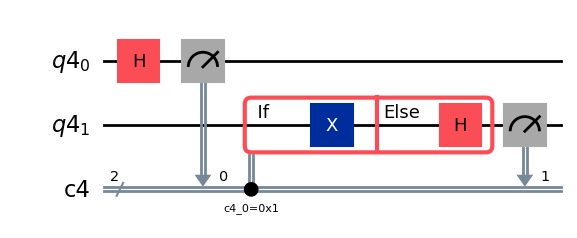

In [ ]:
qubits = QuantumRegister(2)
clbits = ClassicalRegister(2)
circuit = QuantumCircuit(qubits, clbits)

(q0,q1) = qubits
(c0,c1) = clbits

circuit.h(q0) # Apply Hadamard: |0⟩ → (|0⟩ + |1⟩)/√2
circuit.measure(q0, c0) # Measure qubit and store result in classical bit

# Step 2: Conditional operation based on measurement result
with circuit.if_test((c0, 1)) as else_:
  circuit.x(q1)    # X gate is applied on q1 if c0 == 1
with else_:
  circuit.h(q1)    # H gate is applied on q1 if c0 == 0

# Step 3: Measure c1 to see the effect of conditional operation
circuit.measure(q1, c1)

circuit.draw("mpl")

# - If first measurement gives |1⟩ (c0=1): X gate applied, second measurement gives c1=1
# - If first measurement gives |0⟩ (c0=0): H gate is applied on q1, c1 has 50% propability of being 1 and 50% of being 0

# Output {'00': 25%, '10': 25%, '11': 50%}

### **Multi-bit Classical Register Conditions**

The same conditional logic can be applied to classical registers with multiple bits, enabling more complex decision-making based on multi-qubit measurement outcomes.

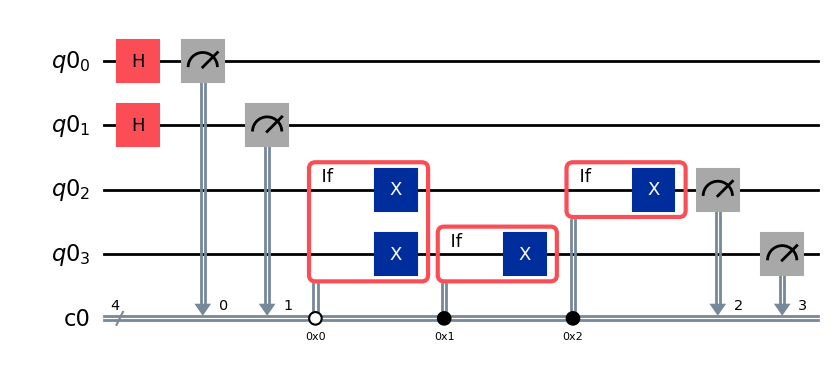

In [ ]:
qubits = QuantumRegister(4)
clbits = ClassicalRegister(4)
circuit = QuantumCircuit(qubits, clbits)

(q0,q1,q2,q3) = qubits
(c0,c1,c2,c3) = clbits

circuit.h([q0,q1])      # Apply Hadamard: |00⟩ → (|00⟩ + |01⟩ + |10⟩ + |11⟩)/2
circuit.measure([q0,q1], [c0,c1])  # Measure qubits and store result in classical bits

# Step 2: Conditional operation based on measurement result
with circuit.if_test((clbits, 0b0000)):
  circuit.x(q2)      # X gate is applied on q2 if c1c0 == 00
  circuit.x(q3)      # x gate is applied on q3 if c1c0 == 00
with circuit.if_test((clbits, 0b0001)):
  circuit.x(q3)     # X gate is applied on q3 if c1c0 == 01
with circuit.if_test((clbits, 0b0010)):
  circuit.x(q2)    # X gate is applied on q2 if c1c0 == 10


# Step 3: Measure c1 to see the effect of conditional operation
circuit.measure([q2,q3], [c2,c3])

circuit.draw("mpl")




### Advanced Classical Expressions

Qiskit supports complex classical expressions using the `expr` module, enabling sophisticated conditional logic based on multiple classical bits and their relationships.

In [ ]:
qr =  QuantumRegister(4, 'q')
cr = ClassicalRegister(3, 'c')
cr2 = ClassicalRegister(1, 'c2')
circuit = QuantumCircuit(qr, cr, cr2)


# Create superposition on first three qubits
circuit.h(qr[0])
circuit.h(qr[1])
circuit.h(qr[2])
circuit.measure(qr[0:3], cr)  # Measure first three qubits

# Create complex condition: XOR of all three classical bits
# This checks the parity (even/odd number of 1's)

_condition = expr.bit_xor(expr.bit_xor(cr[0], cr[1]), cr[2])

# Apply X gate to fourth qubit if parity is odd (XOR result is 1)
with circuit.if_test(_condition):
  circuit.x(qr[3])

circuit.measure(qr[3], cr2)

circuit.draw('mpl')

backend = GenericBackendV2(num_qubits=len(circuit.qubits), control_flow=True)
transpiled_circuit = transpile(circuit, backend)
result = backend.run(transpiled_circuit).result()
print(result.get_counts())


{'0 100': 1, '1 010': 111, '1 110': 1, '0 101': 133, '0 011': 147, '0 110': 143, '1 111': 129, '0 010': 1, '0 000': 115, '1 100': 120, '1 001': 123}


### Finding backend that support dynamic circuits

Not all backends support dynamic circuits,  The code below checks which backends in your IBM Quantum account support this feature.

In [ ]:
# Initialize the service (update credentials if not saved)
# service = QiskitRuntimeService(token="<cloud_api_key>", instance="<instance_CRN>")

dc_backends = service.backends(dynamic_circuits=True)
for backend in dc_backends:
  print(backend.name)

### Qiskit Runtime Limitations of Classical Control Flow

Important constraints when using classical conditionals in Qiskit:

* **Bit Limit**: Operands in `if_test` statements must be 32 or fewer bits, if you compare a classical register , it has to be less than 32 bits.
* **Broadcasting**: Qiskit Runtime cannot broadcast "transfer data to control logic" more than 60 bits at a time (use barriers to manage different broadcasts).
* **No Nesting**: Nested conditionals (if_test inside another if_test) are not supported.
* **No Reset/Measure in Conditionals**: Reset or measurement operations inside conditionals are not supported.
* **No Arithmetic**: Arithmetic operations within classical expressions are not supported.
* ``` for, while``` and ``` switch``` instructions are not supported.

These limitations are important to consider when designing complex classical feedforward circuits.